# 逻辑回归模型

In [79]:
# 定义模型

from sklearn.linear_model import LogisticRegression

logit_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter = 1000,
                                     class_weight = 'balanced',
                                     random_state = 42))
])

In [80]:
# 训练模型
logit_pipeline.fit(x_train, y_train)

/Users/zhengleer/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>))]),
                                                  ['annualIncome',
                                                   'installment']),
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [81]:
# 模型评估


In [82]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix)

def model_evaluation(model, x, y, datasetname = 'dataset', threshold = 0.5):
    y_prob = model.predict_proba(x)[:,1]
    y_pred = (y_prob > threshold).astype(int)
    
    print(datasetname)
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1       :", f1_score(y, y_pred))
    print("ROC-AUC  :", roc_auc_score(y, y_prob))
    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

In [83]:

model_evaluation(logit_pipeline, x_train, y_train, datasetname = 'Train')
model_evaluation(logit_pipeline, x_valid, y_valid, datasetname = 'Valid')

Train
Accuracy : 0.6563767857142857
Precision: 0.3184121469587601
Recall   : 0.6332847028918703
F1       : 0.4237600280290712
ROC-AUC  : 0.7042409302938915
Confusion Matrix:
[[296816 151457]
 [ 40972  70755]]
Valid
Accuracy : 0.65514375
Precision: 0.3165691208253798
Recall   : 0.6286260259382245
F1       : 0.421084659693005
ROC-AUC  : 0.7026275911104735
Confusion Matrix:
[[84756 43322]
 [11855 20067]]


评价：

AUC 还可以

泛化稳定

Recall 较高

Precision 偏低

In [84]:
# 阈值调整

y_valid_prob = logit_pipeline.predict_proba(x_valid)[:,1]
# 阈值评估函数

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
result = []
for t in thresholds:
    y_valid_pred = (y_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

,Accuracy,Precision,Recall,F1,ROC-AUC
0.5,0.655144,0.316569,0.628626,0.421085,0.702628
0.4,0.522525,0.270488,0.820970,0.406909,0.702628
0.6,0.742181,0.370564,0.418332,0.393002,0.702628
0.3,0.371550,0.233127,0.939039,0.373523,0.702628
0.2,0.246350,0.208276,0.991479,0.344239,0.702628
0.1,0.201275,0.199823,0.999655,0.333069,0.702628
0.7,0.786669,0.434959,0.231596,0.302255,0.702628
0.8,0.801181,0.510356,0.085678,0.146724,0.702628
0.9,0.800800,0.576687,0.005889,0.011660,0.702628


In [85]:
# 模型保存

import os
os.makedirs('saved_models', exist_ok = True)

In [86]:
import joblib

joblib.dump(logit_pipeline, "saved_models/logit_pipeline.pkl")

['saved_models/logit_pipeline.pkl']

## 逻辑回归模型性能可视化

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, average_precision_score,
                            confusion_matrix, ConfusionMatrixDisplay)

y_valid_pred_04 = (y_valid_prob > 0.4).astype(int)

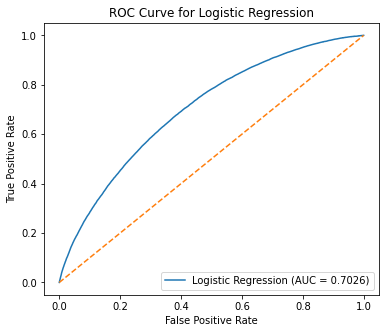

In [38]:
# ROC 曲线

fpr, tpr, _ = roc_curve(y_valid, y_valid_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5))
plt.plot(fpr, tpr, label = f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend(loc = 'lower right')
plt.show()

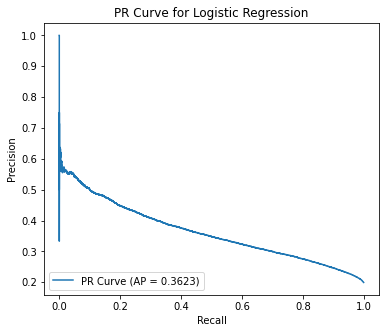

In [39]:
# PR曲线

precision_curve, recall_curve, _ = precision_recall_curve(y_valid, y_valid_prob)
ap_score = average_precision_score(y_valid, y_valid_prob)

plt.figure(figsize = (6,5))
plt.plot(recall_curve, precision_curve, label = f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve for Logistic Regression')
plt.legend(loc = 'lower left')
plt.show()

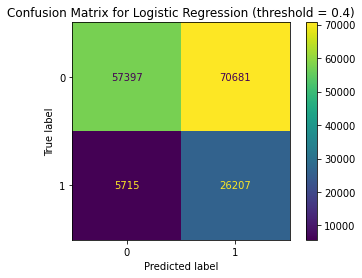

In [40]:
# 混淆矩阵

cm = confusion_matrix(y_valid, y_valid_pred_04)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(values_format = 'd')
plt.title('Confusion Matrix for Logistic Regression (threshold = 0.4)')
plt.show()

## 逻辑回归模型优化

In [ ]:


# 连续型数值变量（对数变换）
log_serial_num_transformer_v2 = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

# 连续型数值变量（99分位数截尾）
winsor_serial_num_transformer_v2 = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('winsor', Winsorizer(upper_quantile=0.99)),
    ('scaler', StandardScaler())
])

# 普通数值型+分类变量，只用填充缺失值
normal_num_transformer_v2 = Pipeline(steps= [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

logit_preprocessor = ColumnTransformer(
    transformers = [
        ('normal_num_transformer', normal_num_transformer_v2, remaining_num_features),
        ('low_card_cat_transformer', low_card_cat_transformer, low_card_cat_features),
        ('high_card_cat_simple_transformer', high_card_cat_simple_transformer, high_card_cat_simple_features),
        ('high_card_cat_rare_transformer', high_card_cat_rare_transformer, high_card_cat_rare_features),
        ('log_serial_num_transformer', log_serial_num_transformer_v2, log_serial_num_features),
        ('winsor_serial_num_transformer', winsor_serial_num_transformer_v2, winsor_serial_num_features)
    ],
    remainder = 'drop')

In [107]:
logit_pipeline_v2 = Pipeline(steps = [
    ('preprocessor', logit_preprocessor),
    ('classifier', LogisticRegression(max_iter = 1000,
                                     class_weight = 'balanced',
                                     random_state = 42))
])

logit_pipeline_v2.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n...
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['annualIncome',
                                                   'installment']),
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [108]:
model_evaluation(logit_pipeline_v2, x_train, y_train, datasetname = 'Train')
model_evaluation(logit_pipeline_v2, x_valid, y_valid, datasetname = 'Valid')

Train
Accuracy : 0.6624982142857143
Precision: 0.3259625952685537
Recall   : 0.6476948275707752
F1       : 0.4336726285541349
ROC-AUC  : 0.71575541997567
Confusion Matrix:
[[298634 149639]
 [ 39362  72365]]
Valid
Accuracy : 0.6603875
Precision: 0.3236127285889648
Recall   : 0.6441638995050435
F1       : 0.4308011396966396
ROC-AUC  : 0.7135421119444456
Confusion Matrix:
[[85099 42979]
 [11359 20563]]


In [111]:
# 阈值调整

y_valid_prob_logit_pipeline_v2 = logit_pipeline_v2.predict_proba(x_valid)[:,1]
# 阈值评估函数

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
result = []
for t in thresholds:
    y_valid_pred = (y_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

,Accuracy,Precision,Recall,F1,ROC-AUC
0.5,0.660388,0.323613,0.644164,0.430801,0.713542
0.4,0.534719,0.275682,0.818558,0.412454,0.713542
0.6,0.745006,0.380296,0.441733,0.408719,0.713542
0.3,0.391656,0.238396,0.933682,0.379815,0.713542
0.2,0.267544,0.212588,0.987908,0.349885,0.713542
0.1,0.203706,0.200319,0.999718,0.333760,0.713542
0.7,0.788094,0.445453,0.253650,0.323240,0.713542
0.8,0.802806,0.529468,0.104411,0.174425,0.713542
0.9,0.801144,0.598131,0.010024,0.019718,0.713542


In [110]:
joblib.dump(logit_pipeline_v2, "saved_models/logit_pipeline_v2.pkl")

['saved_models/logit_pipeline_v2.pkl']

# 随机森林模型

In [41]:
# 定义模型

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 200,
                                         max_depth = 200,
                                         min_samples_split = 50,
                                         min_samples_leaf = 20,
                                         class_weight = 'balanced_subsample',
                                         random_state = 42,
                                         n_jobs = -1))
])

rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=200, min_samples_leaf=20,
                                        min_samples_split=50, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [42]:
# 模型评估

model_evaluation(rf_pipeline, x_train, y_train, datasetname = 'Train')
model_evaluation(rf_pipeline, x_valid, y_valid, datasetname = 'Valid')

Train
Accuracy : 0.7754607142857143
Precision: 0.46145553153688335
Recall   : 0.7508838508149328
F1       : 0.5716212993561135
ROC-AUC  : 0.8539488194407929
Confusion Matrix:
[[350364  97909]
 [ 27833  83894]]
Valid
Accuracy : 0.7035
Precision: 0.34851620460757515
Recall   : 0.5592068166155003
F1       : 0.4294099251882322
ROC-AUC  : 0.71707446711201
Confusion Matrix:
[[94709 33369]
 [14071 17851]]


In [43]:
# 存在过拟合问题--调整模型参数

rf_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=100,
        min_samples_leaf=50,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_v2.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                                                   'installment']),
                                                 ('winsor_serial_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('winsor',
                                                                   Winsorizer())]),
                                                  ['loanAmnt', 'interestRate',
                                                   'dti_cleaned',
                                                   'revolUtil'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=8, min_samples_leaf=50,
                                        min_samples_split=100, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [44]:
model_evaluation(rf_pipeline_v2, x_train, y_train, datasetname = 'Train')
model_evaluation(rf_pipeline_v2, x_valid, y_valid, datasetname = 'Valid')

Train
Accuracy : 0.6338428571428572
Precision: 0.31246910355083096
Recall   : 0.6958658157831142
F1       : 0.43127846409017534
ROC-AUC  : 0.7178603472645828
Confusion Matrix:
[[277205 171068]
 [ 33980  77747]]
Valid
Accuracy : 0.62878125
Precision: 0.3076739985718886
Recall   : 0.6883967169976819
F1       : 0.42527456577483186
ROC-AUC  : 0.7103267307587283
Confusion Matrix:
[[78630 49448]
 [ 9947 21975]]


In [88]:
# 仍选择第一版模型
# 保存模型

joblib.dump(logit_pipeline, "saved_models/rf_pipeline.pkl")

['saved_models/rf_pipeline.pkl']

In [87]:




# 阈值调整

rf_y_valid_prob = rf_pipeline.predict_proba(x_valid)[:,1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
result = []
for t in thresholds:
    y_valid_pred = (rf_y_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, rf_y_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

/Users/zhengleer/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1,ROC-AUC
0.5,0.703500,0.348516,0.559207,0.429410,0.717074
0.4,0.590031,0.294534,0.756062,0.423923,0.717074
0.3,0.455788,0.254334,0.894336,0.396041,0.717074
0.6,0.776625,0.424706,0.337322,0.376004,0.717074
0.2,0.318150,0.222739,0.971086,0.362362,0.717074
0.1,0.225038,0.204416,0.997337,0.339291,0.717074
0.7,0.803019,0.523103,0.143631,0.225379,0.717074
0.8,0.802381,0.671574,0.018577,0.036153,0.717074
0.9,0.800488,0.000000,0.000000,0.000000,0.717074


In [46]:
rf_y_valid_pred_04 = (rf_y_valid_prob > 0.4).astype(int)

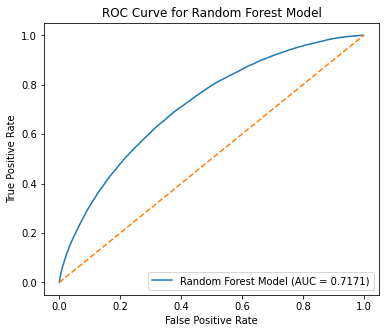

In [47]:
# ROC曲线

fpr, tpr, _ = roc_curve(y_valid, rf_y_valid_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5))
plt.plot(fpr, tpr, label = f'Random Forest Model (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Model')
plt.legend(loc = 'lower right')
plt.show()

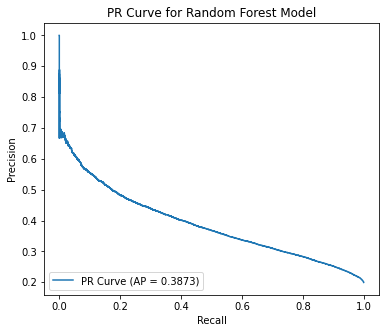

In [48]:
# PR曲线

precision_curve, recall_curve, _ = precision_recall_curve(y_valid, rf_y_valid_prob)
ap_score = average_precision_score(y_valid, rf_y_valid_prob)

plt.figure(figsize = (6,5))
plt.plot(recall_curve, precision_curve, label = f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve for Random Forest Model')
plt.legend(loc = 'lower left')
plt.show()

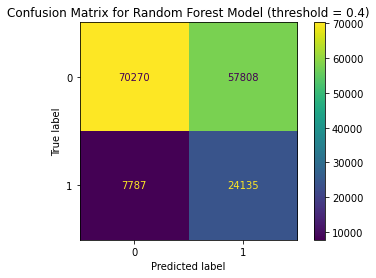

In [49]:
# 混淆矩阵

cm = confusion_matrix(y_valid, rf_y_valid_pred_04)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(values_format = 'd')
plt.title('Confusion Matrix for Random Forest Model (threshold = 0.4)')
plt.show()

# 模型对比评估

In [112]:


result = []

y_valid_pred_04 = (y_valid_prob_logit_pipeline_v2 > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, y_valid_pred_04),
    'Precision':precision_score(y_valid, y_valid_pred_04),
    'Recall':recall_score(y_valid, y_valid_pred_04),
    'F1':f1_score(y_valid, y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)})

rf_y_valid_pred_04 = (rf_y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, rf_y_valid_pred_04),
    'Precision':precision_score(y_valid, rf_y_valid_pred_04),
    'Recall':recall_score(y_valid, rf_y_valid_pred_04),
    'F1':f1_score(y_valid, rf_y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, rf_y_valid_prob)})

compare_df = pd.DataFrame(result,
                         index = ['Logic Regression','Random Forest Model'])
compare_df




,Accuracy,Precision,Recall,F1,ROC-AUC
Logic Regression,0.534719,0.275682,0.818558,0.412454,0.713542
Random Forest Model,0.590031,0.294534,0.756062,0.423923,0.717074


# XGBoost

In [51]:
import sys
!{sys.executable} -m pip install xgboost

In [52]:
from xgboost import XGBClassifier

In [53]:
xgb_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators = 200,
                                max_depth = 4,
                                learning_rate = 0.05,
                                subsample = 0.8,
                                colsample_bytree = 0.8,
                                reg_alpha = 0,
                                reg_lambda = 1,
                                objective = 'binary:logistic',
                                eval_metric = 'logloss',
                                random_state = 42,
                                n_jobs = -1))
])

In [54]:
xgb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('normal_num_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['delinquency_2years',
                                                   'pubRec',
                                                   'pubRecBankruptcies',
                                                   'ficoRangeLow', 'openAcc',
                                                   'revolBal', 'totalAcc', 'n0',
                                                   'n1', 'n2', 'n3', 'n4', 'n5',
                                                   'n6', 'n7', 'n8', 'n9',
                                                   'n10', 'n11', 'n12', 'n13',
                                                   'n14',
                                                   'credit_history_ye...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, random_state=42, ...))])

In [55]:
model_evaluation(xgb_pipeline, x_train, y_train, datasetname = 'Train')
model_evaluation(xgb_pipeline, x_valid, y_valid, datasetname = 'Valid')

Train
Accuracy : 0.8049464285714286
Precision: 0.595663167573366
Recall   : 0.0695803163067119
F1       : 0.12460529901104361
ROC-AUC  : 0.725371125354175
Confusion Matrix:
[[442996   5277]
 [103953   7774]]
Valid
Accuracy : 0.805
Precision: 0.5946016771488469
Recall   : 0.07107950629659796
F1       : 0.12697968548883543
ROC-AUC  : 0.7187141966703712
Confusion Matrix:
[[126531   1547]
 [ 29653   2269]]


In [56]:
# 阈值调整

# 阈值调整

xgb_y_valid_prob = xgb_pipeline.predict_proba(x_valid)[:,1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
result = []
for t in thresholds:
    y_valid_pred = (xgb_y_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, xgb_y_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

/Users/zhengleer/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/zhengleer/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Precision,Recall,F1,ROC-AUC
0.2,0.644437,0.316880,0.676743,0.431646,0.718714
0.3,0.762294,0.403743,0.401479,0.402607,0.718714
0.1,0.406169,0.242113,0.927761,0.384012,0.718714
0.4,0.798931,0.490139,0.193848,0.277819,0.718714
0.5,0.805000,0.594602,0.071080,0.126980,0.718714
0.6,0.801837,0.673633,0.013126,0.025750,0.718714
0.7,0.800600,0.950000,0.000595,0.001190,0.718714
0.8,0.800488,0.000000,0.000000,0.000000,0.718714
0.9,0.800488,0.000000,0.000000,0.000000,0.718714


In [57]:
# 阈值调整

thresholds = [0.15, 0.2,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.3]
result = []
for t in thresholds:
    y_valid_pred = (xgb_y_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, xgb_y_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

,Accuracy,Precision,Recall,F1,ROC-AUC
0.22,0.677944,0.334515,0.620794,0.434760,0.718714
0.23,0.692388,0.342981,0.591755,0.434263,0.718714
0.24,0.706200,0.352214,0.563154,0.433379,0.718714
0.21,0.661431,0.325216,0.648424,0.433174,0.718714
0.20,0.644437,0.316880,0.676743,0.431646,0.718714
0.25,0.717856,0.360258,0.533864,0.430207,0.718714
0.26,0.728838,0.368875,0.505138,0.426384,0.718714
0.27,0.738637,0.377494,0.477633,0.421700,0.718714
0.28,0.747625,0.386677,0.452039,0.416811,0.718714
0.15,0.540913,0.278302,0.816616,0.415129,0.718714


In [58]:
xgb_y_valid_pred_023 = (xgb_y_valid_prob > 0.23).astype(int)

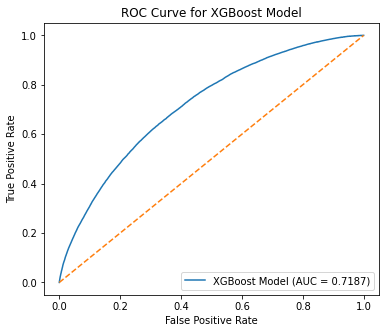

In [59]:
# ROC曲线

fpr, tpr, _ = roc_curve(y_valid, xgb_y_valid_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (6,5))
plt.plot(fpr, tpr, label = f'XGBoost Model (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Model')
plt.legend(loc = 'lower right')
plt.show()

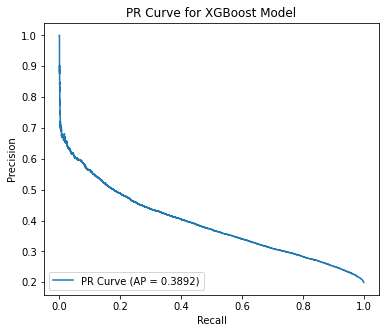

In [60]:
# PR曲线

precision_curve, recall_curve, _ = precision_recall_curve(y_valid, xgb_y_valid_prob)
ap_score = average_precision_score(y_valid, xgb_y_valid_prob)

plt.figure(figsize = (6,5))
plt.plot(recall_curve, precision_curve, label = f'PR Curve (AP = {ap_score:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve for XGBoost Model')
plt.legend(loc = 'lower left')
plt.show()

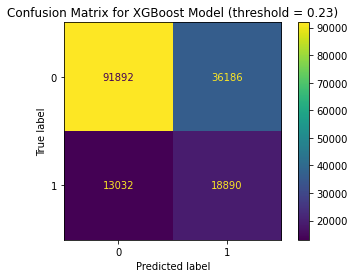

In [61]:
# 混淆矩阵

cm = confusion_matrix(y_valid, xgb_y_valid_pred_023)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(values_format = 'd')
plt.title('Confusion Matrix for XGBoost Model (threshold = 0.23)')
plt.show()

# 模型优化

In [62]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

In [124]:
# 1. 定义基础模型
xgb_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42))
])



# 2. 定义参数空间
params = {
    'classifier__n_estimators': [100, 200, 300], # 树的数量，可理解为 boosting 迭代次数
    'classifier__max_depth': [3, 4, 5, 6], # 每棵树的最大深度
    'classifier__learning_rate': [0.03, 0.05, 0.1], # 学习率，控制每棵树对最终结果的贡献大小
    'classifier__min_child_weight': [1, 3, 5], # 子节点最小样本权重和
    'classifier__subsample': [0.8, 0.9, 1.0], # 每棵树训练时随机抽取的样本比例
    'classifier__colsample_bytree': [0.8, 0.9, 1.0], # 每棵树训练时随机抽取的特征比例
    'classifier__scale_pos_weight': [3, 4, 5]    # 给正类更高权重，用于缓解类别不平衡
}

# 3. 定义分层K折交叉验证
skf = StratifiedKFold(n_splits=3,  # 将训练数据分成3折，每次用其中1折做验证，其余4折做训练
                      shuffle=True, # 在分折之前先将样本随机打乱，避免原始数据顺序带来偏差
                      random_state=42)

# 4. 随机搜索
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=params,
    n_iter=4,               
    scoring='roc_auc',
    cv=skf,
    verbose=2, # 输出较详细的训练过程信息，便于观察搜索进度
    random_state=42,
    n_jobs=1
)

# 5. 开始训练
random_search.fit(x_train, y_train)

# 6. 输出最优参数和最优AUC
print("Best Params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   7.3s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   7.1s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=5, classifier__min_child_weight=3, classifier__n_estimators=300, classifier__scale_pos_weight=4, classifier__subsample=1.0; total time=   6.9s
[CV] END classifier__colsample_bytree=0.9, classifier__learning_rate=0.03, classifier__max_depth=6, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__scale_pos_weight=5, classifier__subsample=0.9; to

In [98]:
best_xgb = random_search.best_estimator_

# 保存模型

joblib.dump(logit_pipeline, "saved_models/best_xgb.pkl")

['saved_models/best_xgb.pkl']

In [90]:
best_xgb_valid_prob = best_xgb.predict_proba(x_valid)[:,1]
print('AUC score:', roc_auc_score(y_valid, best_xgb_valid_prob))

AUC score: 0.7264652927066965


In [91]:
# 阈值调整

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
result = []
for t in thresholds:
    y_valid_pred = (best_xgb_valid_prob > t).astype(int)
    result.append({
        'Accuracy':accuracy_score(y_valid, y_valid_pred),
        'Precision':precision_score(y_valid, y_valid_pred),
        'Recall':recall_score(y_valid, y_valid_pred),
        'F1':f1_score(y_valid, y_valid_pred),
        'ROC-AUC':roc_auc_score(y_valid, best_xgb_valid_prob)
    })

threshold_classifier_df = pd.DataFrame(result,
                                      index = thresholds)
threshold_classifier_df.sort_values('F1', ascending = False)

,Accuracy,Precision,Recall,F1,ROC-AUC
0.5,0.657275,0.326119,0.673141,0.439373,0.726465
0.6,0.744631,0.387019,0.479513,0.428330,0.726465
0.4,0.545906,0.281642,0.822912,0.419656,0.726465
0.3,0.425256,0.247606,0.922530,0.390423,0.726465
0.2,0.308175,0.221137,0.978385,0.360738,0.726465
0.7,0.793588,0.469846,0.269438,0.342478,0.726465
0.1,0.227331,0.204945,0.997713,0.340040,0.726465
0.8,0.805781,0.590433,0.086617,0.151072,0.726465
0.9,0.800844,0.711111,0.003007,0.005989,0.726465


# Logistic, RandomForest, XGBoost模型对比

In [92]:
result = []

y_valid_pred_04 = (y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, y_valid_pred_04),
    'Precision':precision_score(y_valid, y_valid_pred_04),
    'Recall':recall_score(y_valid, y_valid_pred_04),
    'F1':f1_score(y_valid, y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)})

rf_y_valid_pred_04 = (rf_y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, rf_y_valid_pred_04),
    'Precision':precision_score(y_valid, rf_y_valid_pred_04),
    'Recall':recall_score(y_valid, rf_y_valid_pred_04),
    'F1':f1_score(y_valid, rf_y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, rf_y_valid_prob)})

xgb_y_valid_pred_04 = (best_xgb_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, xgb_y_valid_pred_04),
    'Precision':precision_score(y_valid, xgb_y_valid_pred_04),
    'Recall':recall_score(y_valid, xgb_y_valid_pred_04),
    'F1':f1_score(y_valid, xgb_y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, best_xgb_valid_prob)})

compare_df = pd.DataFrame(result,
                         index = ['Logic Regression','Random Forest Model','XGBoost Model'])
compare_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logic Regression,0.522525,0.270488,0.820970,0.406909,0.702628
Random Forest Model,0.590031,0.294534,0.756062,0.423923,0.717074
XGBoost Model,0.545906,0.281642,0.822912,0.419656,0.726465


# SHAP模型解释

In [93]:
!pip install shap

In [94]:
%pip uninstall -y shap numpy pandas scipy scikit-learn matplotlib contourpy slicer
%pip install numpy==1.26.4 pandas==2.2.3 scipy==1.13.1 scikit-learn==1.5.2 matplotlib==3.8.4 shap==0.46.0

Found existing installation: shap 0.46.0
Uninstalling shap-0.46.0:
  Successfully uninstalled shap-0.46.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.3
Uninstalling pandas-2.2.3:
  Successfully uninstalled pandas-2.2.3
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
Found existing installation: matplotlib 3.8.4
Uninstalling matplotlib-3.8.4:
  Successfully uninstalled matplotlib-3.8.4
Found existing installation: contourpy 1.3.0
Uninstalling contourpy-1.3.0:
  Successfully uninstalled contourpy-1.3.0
Found existing installation: slicer 0.0.8
Uninstalling slicer-0.0.8:
  Successfully uninstalled slicer-0.0.8
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.

In [3]:
%pip install numexpr==2.10.1 bottleneck==1.4.2

     |████████████████████████████████| 141 kB 847 kB/s eta 0:00:01
     |████████████████████████████████| 103 kB 4.2 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for bottleneck: filename=bottleneck-1.4.2-cp39-cp39-macosx_10_9_x86_64.whl size=111582 sha256=458f3aa168463277548b29b5dec3189b4e8651eda60cb082b62b82584a9967b2
  Stored in directory: /Users/zhengleer/Library/Caches/pip/wheels/c9/90/4e/448a41209acac6bdc6bb04ac4493961dd1ca836576cee66a2a
Successfully built bottleneck
  Attempting uninstall: numexpr
    Found existing installation: numexpr 2.10.2
    Uninstalling numexpr-2.10.2:
      Successfully uninstalled numexpr-2.10.2
  Attempting uninstall: bottleneck
    Found existing installation: bottleneck 1.5.0
    Uninstalling bottleneck-1.5.0:
      Successfully uninstalled bottleneck-1.5.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import shap
import matplotlib.pyplot as plt

In [100]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(x_valid)

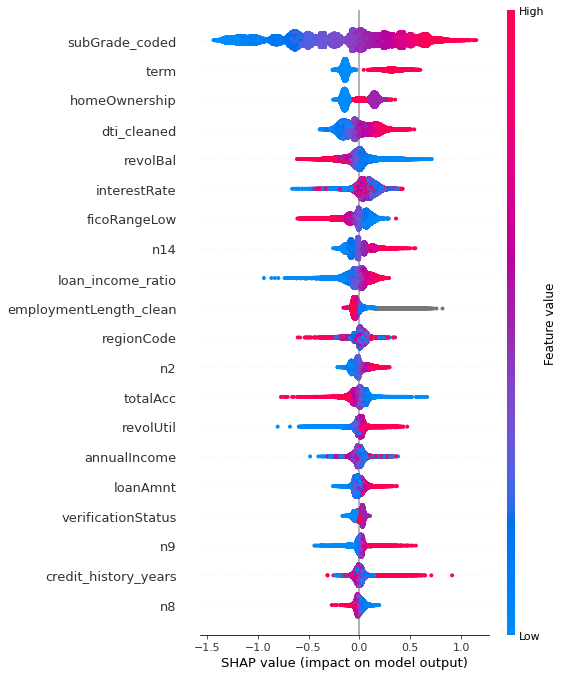

In [101]:
shap.summary_plot(shap_values, x_valid)

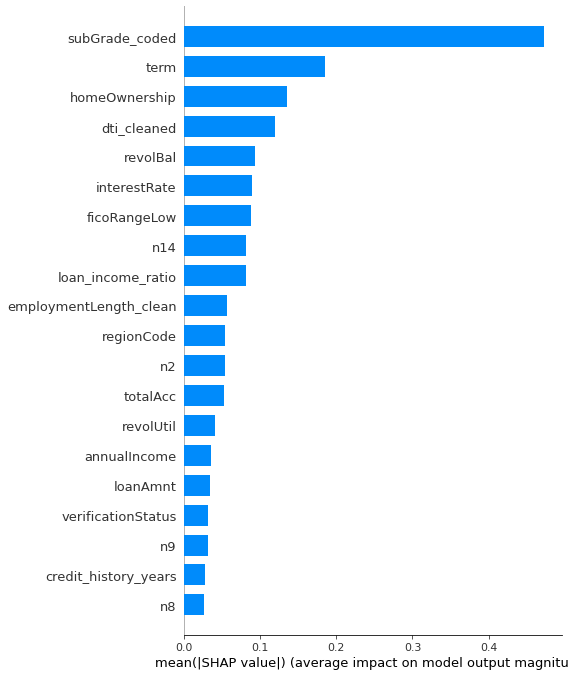

In [102]:
shap.summary_plot(shap_values, x_valid, plot_type="bar")

# 测试集最终评估

In [117]:
best_xgb_test_prob = best_xgb.predict_proba(x_test)[:, 1]
print('AUC score:', roc_auc_score(y_test, best_xgb_test_prob))

y_test_pred_04 = (best_xgb_test_prob > 0.4).astype(int)

print('Accuracy:', accuracy_score(y_test, y_test_pred_04))
print('Precision:', precision_score(y_test, y_test_pred_04))
print('Recall:', recall_score(y_test, y_test_pred_04))
print('F1:', f1_score(y_test, y_test_pred_04))

AUC score: 0.7258100213055922
Accuracy: 0.5469
Precision: 0.2817898246746262
Recall: 0.8206879268216277
F1: 0.419530474329821


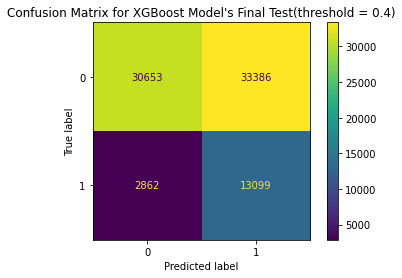

In [119]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_test_pred_04)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(values_format = 'd')
plt.title('Confusion Matrix for XGBoost Model\'s Final Test(threshold = 0.4)')
plt.show()

In [126]:
# 泛化能力分析

y_train_prob = best_xgb.predict_proba(x_train)[:, 1]
y_valid_prob = best_xgb.predict_proba(x_valid)[:, 1]
y_test_prob = best_xgb.predict_proba(x_test)[:, 1]

result = []

y_train_pred_04 = (y_train_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_train, y_train_pred_04),
    'Precision':precision_score(y_train, y_train_pred_04),
    'Recall':recall_score(y_train, y_train_pred_04),
    'F1':f1_score(y_train, y_train_pred_04),
    'ROC-AUC':roc_auc_score(y_train, y_train_prob)})

y_valid_pred_04 = (y_valid_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_valid, y_valid_pred_04),
    'Precision':precision_score(y_valid, y_valid_pred_04),
    'Recall':recall_score(y_valid, y_valid_pred_04),
    'F1':f1_score(y_valid, y_valid_pred_04),
    'ROC-AUC':roc_auc_score(y_valid, y_valid_prob)})

y_test_pred_04 = (y_test_prob > 0.4).astype(int)
result.append({'Accuracy':accuracy_score(y_test, y_test_pred_04),
    'Precision':precision_score(y_test, y_test_pred_04),
    'Recall':recall_score(y_test, y_test_pred_04),
    'F1':f1_score(y_test, y_test_pred_04),
    'ROC-AUC':roc_auc_score(y_test, y_test_prob)})

compare_df = pd.DataFrame(result,
                         index = ['Train','Valid','Test'])
compare_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Train,0.556382,0.289922,0.844263,0.431624,0.748864
Valid,0.545906,0.281642,0.822912,0.419656,0.726465
Test,0.546900,0.281790,0.820688,0.419530,0.725810
